# BANK CUSTOMER SEGMENTATION PROJECT - ANALYSIS SUMMARY  by Alisa Pecherskaya   
# dowload data: https://www.kaggle.com/datasets/shivamb/bank-customer-segmentation 


OVERALL PROJECT GOAL:
Transform raw transaction data into a comprehensive, actionable customer segmentation strategy to identify high-value customer groups, mitigate financial risks, and drive measurable growth in average transaction volume and customer lifetime value.

PHASE 1: DATA CLEANING

What You Wanted to Achieve:
Prepare reliable, accurate data for analysis by eliminating errors, inconsistencies, and invalid records.

1.	Loaded 1M+ transaction records
2.	Removed 6,953 rows with missing values
3.	Eliminated duplicate CustomerIDs
4.	Filtered unrealistic dates (year 1800)
5.	Converted dates to proper datetime format
6.	Fixed century interpretation errors (2057 → 1957)
7.	Removed outliers in account balances and transaction amounts

Result: 644,213 clean, unique records


PHASE 2: EXPENDITURE DISTRIBUTION ANALYSIS

Understand spending behavior patterns across different demographic and financial segments to identify high-value and low-value customer groups.


1.	Calculated customer ages from birth dates
2.	Created 6 age groups (18-25, 26-35, 36-45, 46-55, 56-65, 65+)
3.	Created 5 balance groups using quantiles (Low to High)
4.	Analyzed spending patterns by:
5.
•	Gender (Male vs Female)
•	Age groups
•	Balance groups


PHASE 3: COMBINED ANALYSIS

Discover specific customer segments with unique spending behaviors by examining how multiple factors interact, revealing hidden patterns not visible in single-variable analysis.

1.	Multi-dimensional analysis combining Gender × Age × Balance
2.	Created crosstab tables showing average spending for all combinations
3.	Identified extreme segments (highest and lowest spenders)

PHASE 4: DATA VISUALIZATION

Present complex findings visually to make patterns immediately clear and communicate insights effectively to stakeholders who need quick, actionable intelligence.

•	Gender distribution pie chart
•	Age/gender spending bar charts
•	Balance group horizontal bar chart
•	Multi-dimensional heatmap (Gender × Age × Balance)

PHASE 5: EXECUTIVE CUSTOMER INSIGHTS & STRATEGY REPORT

1.	Full Data Understanding
2.	Strategic Recommendations
3.	Actions & Implementation Plan
4.	Measurement & KPIs and Final Executive Takeaway


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from datetime import datetime

Analyzing Bank Customer Segmentation (1M+ Transactions)

About this Dataset:
This dataset consists of 1 Million+ transaction by over 800K customers for a bank in India. The data contains information such as - customer age (DOB), location, gender, account balance at the time of the transaction, transaction details, transaction amount, etc.

Column Descriptions
TransactionID -Unite Transaction ID
CustomerID - Unique Customer ID
CustomerDOB - Date of Birth
CustGender - Gender
CustLocation - Location
CustAccountBalance - Account Balance
TransactionDate - Transaction date
TransactionTime - Transaction time
TransactionAmount (INR) - Amount in INR

In [52]:
#loading the dataset bank_transactions.csv into a DataFrame called bnk.
#Understanding the structure, column names, and the type of values stored.
bnk= pd.read_csv('bank_transactions.csv')
bnk.head()
bnk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB


In [53]:
# We can see that the number of columns is not the same,
# CustomerDOB might have missing birthdates.
#CustAccountBalance may have some customers without balances recorded.
# so we want to find rows with one or more nulls:
bn = bnk.isnull().any(axis=1)
# Count such rows.
#This helps decide what kind of data cleaning is required 
#(drop rows, fill with default values, or convert)
count = bn.sum()
count

np.int64(6953)

1. Cleaning data

In [54]:
bnk= bnk.dropna()

In [55]:
# There is no nulls left = all values are full 
bnk.isna().sum()

TransactionID              0
CustomerID                 0
CustomerDOB                0
CustGender                 0
CustLocation               0
CustAccountBalance         0
TransactionDate            0
TransactionTime            0
TransactionAmount (INR)    0
dtype: int64

In [56]:
# We can see the same numbers at every column
bnk.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1041614 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1041614 non-null  object 
 1   CustomerID               1041614 non-null  object 
 2   CustomerDOB              1041614 non-null  object 
 3   CustGender               1041614 non-null  object 
 4   CustLocation             1041614 non-null  object 
 5   CustAccountBalance       1041614 non-null  float64
 6   TransactionDate          1041614 non-null  object 
 7   TransactionTime          1041614 non-null  int64  
 8   TransactionAmount (INR)  1041614 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 79.5+ MB


In [57]:
# We want to know if there are duplicated values at CustomerID - it must be a unique value

nonunique_count = bnk['CustomerID'].duplicated().sum()
nonunique_count

np.int64(162256)

In [58]:
# Keeping unique rows (remove all duplicates)

bnk = bnk[~bnk['CustomerID'].duplicated(keep=False)]
bnk.info()

<class 'pandas.core.frame.DataFrame'>
Index: 737397 entries, 0 to 1048565
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   TransactionID            737397 non-null  object 
 1   CustomerID               737397 non-null  object 
 2   CustomerDOB              737397 non-null  object 
 3   CustGender               737397 non-null  object 
 4   CustLocation             737397 non-null  object 
 5   CustAccountBalance       737397 non-null  float64
 6   TransactionDate          737397 non-null  object 
 7   TransactionTime          737397 non-null  int64  
 8   TransactionAmount (INR)  737397 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 56.3+ MB


In [59]:
bnk.describe()

,CustAccountBalance,TransactionTime,TransactionAmount (INR)
count,7.373970e+05,737397.000000,7.373970e+05
mean,1.142910e+05,157167.607865,1.567793e+03
std,8.273090e+05,51279.813580,6.789367e+03
min,0.000000e+00,0.000000,0.000000e+00
25%,4.717490e+03,124118.000000,1.610000e+02
50%,1.676471e+04,164306.000000,4.575200e+02
75%,5.738553e+04,200048.000000,1.200000e+03
max,1.150355e+08,235959.000000,1.560035e+06


We use a scatterplot for CustAccountBalance  and Transaction Amount (INR) 
The result is a straight diagonal line, which does not give new insights, 
But gives us a better view of the data.

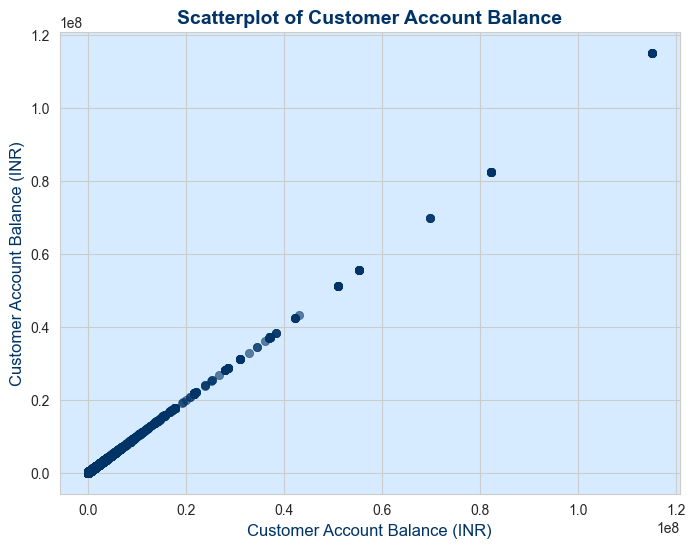

In [60]:
plt.figure(figsize=(8,6))
sb.set_style("whitegrid")  
plt.gca().set_facecolor("#d6ebff")
sb.scatterplot(
    data=bnk,
    x="CustAccountBalance",
    y="CustAccountBalance",
    color="#003366",
    alpha=0.6,
    edgecolor=None
)

plt.title("Scatterplot of Customer Account Balance", fontsize=14, weight='bold', color="#003366")
plt.xlabel("Customer Account Balance (INR)", fontsize=12, color="#003366")
plt.ylabel("Customer Account Balance (INR)", fontsize=12, color="#003366")
plt.show()


In [61]:
# Most of the data is below the 250000 CustAccountBalance
bnk=bnk[bnk['CustAccountBalance']<250000]
bnk.info()

<class 'pandas.core.frame.DataFrame'>
Index: 676735 entries, 0 to 1048565
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   TransactionID            676735 non-null  object 
 1   CustomerID               676735 non-null  object 
 2   CustomerDOB              676735 non-null  object 
 3   CustGender               676735 non-null  object 
 4   CustLocation             676735 non-null  object 
 5   CustAccountBalance       676735 non-null  float64
 6   TransactionDate          676735 non-null  object 
 7   TransactionTime          676735 non-null  int64  
 8   TransactionAmount (INR)  676735 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 51.6+ MB


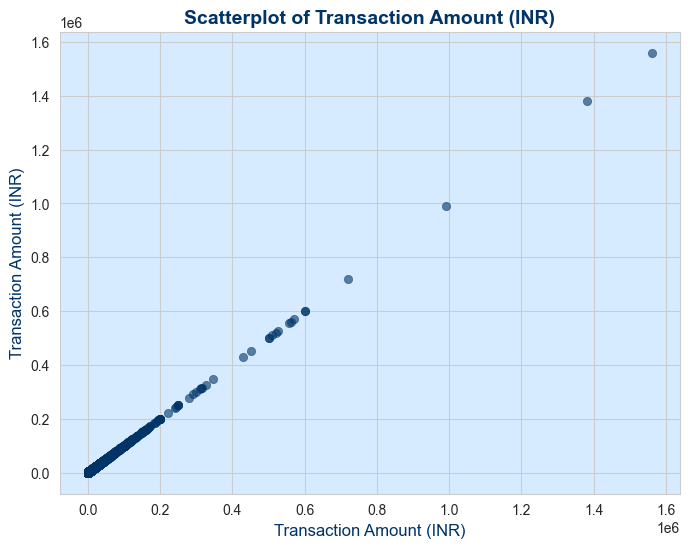

In [62]:
plt.figure(figsize=(8,6))
sb.set_style("whitegrid")  
plt.gca().set_facecolor("#d6ebff") 
sb.scatterplot(
    data=bnk,
    x="TransactionAmount (INR)",
    y="TransactionAmount (INR)",
    color="#003366",
    alpha=0.6,
    edgecolor=None
)

plt.title("Scatterplot of Transaction Amount (INR)", fontsize=14, weight='bold', color="#003366")
plt.xlabel("Transaction Amount (INR)", fontsize=12, color="#003366")
plt.ylabel("Transaction Amount (INR)", fontsize=12, color="#003366")
plt.show()


In [63]:
# Most of the data is below the 360000 TransactionAmount (INR)

bnk=bnk[bnk['TransactionAmount (INR)']<360000]
bnk.info()

<class 'pandas.core.frame.DataFrame'>
Index: 676719 entries, 0 to 1048565
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   TransactionID            676719 non-null  object 
 1   CustomerID               676719 non-null  object 
 2   CustomerDOB              676719 non-null  object 
 3   CustGender               676719 non-null  object 
 4   CustLocation             676719 non-null  object 
 5   CustAccountBalance       676719 non-null  float64
 6   TransactionDate          676719 non-null  object 
 7   TransactionTime          676719 non-null  int64  
 8   TransactionAmount (INR)  676719 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 51.6+ MB


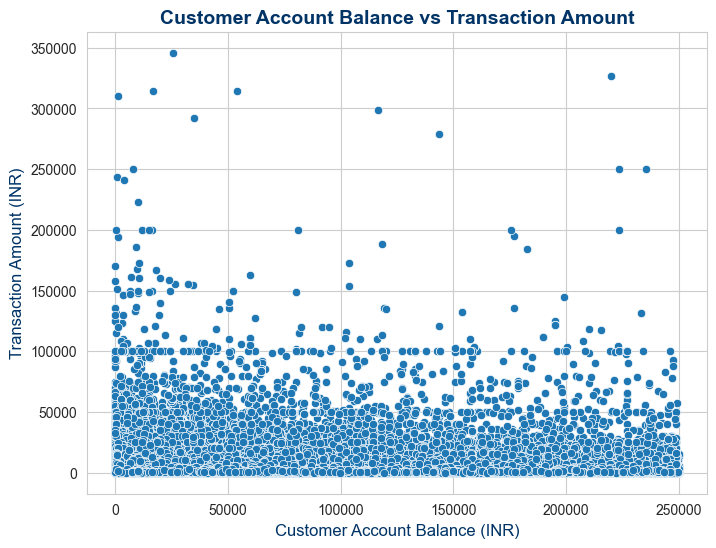

In [64]:
plt.figure(figsize=(8,6))
sb.set_style("whitegrid") 
sb.scatterplot(
    data=bnk,
    x="CustAccountBalance",
    y="TransactionAmount (INR)"
)

plt.title("Customer Account Balance vs Transaction Amount", fontsize=14, weight='bold', color="#003366")
plt.xlabel("Customer Account Balance (INR)", fontsize=12, color="#003366")
plt.ylabel("Transaction Amount (INR)", fontsize=12, color="#003366")
plt.show()


In [65]:
# Most Transaction amounts are below 100000 INR
bnk=bnk[bnk['TransactionAmount (INR)']<100000]
bnk.info()

<class 'pandas.core.frame.DataFrame'>
Index: 676303 entries, 0 to 1048565
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   TransactionID            676303 non-null  object 
 1   CustomerID               676303 non-null  object 
 2   CustomerDOB              676303 non-null  object 
 3   CustGender               676303 non-null  object 
 4   CustLocation             676303 non-null  object 
 5   CustAccountBalance       676303 non-null  float64
 6   TransactionDate          676303 non-null  object 
 7   TransactionTime          676303 non-null  int64  
 8   TransactionAmount (INR)  676303 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 51.6+ MB


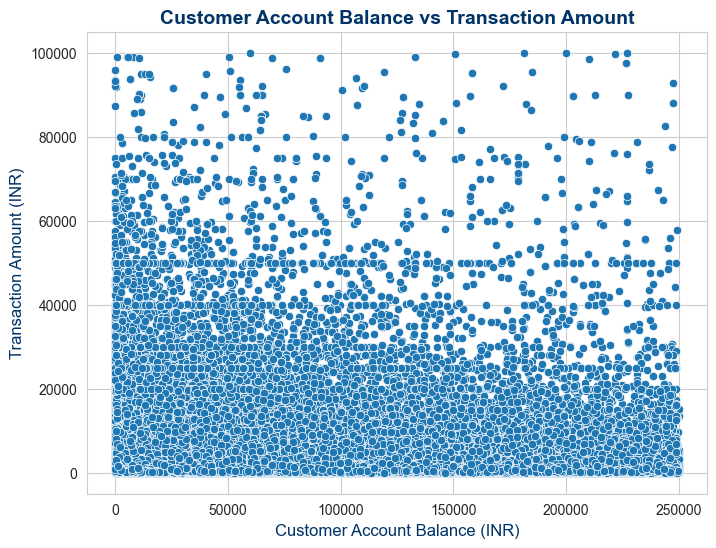

In [66]:
plt.figure(figsize=(8,6))
sb.set_style("whitegrid") 
sb.scatterplot(
    data=bnk,
    x="CustAccountBalance",
    y="TransactionAmount (INR)"
)

plt.title("Customer Account Balance vs Transaction Amount", fontsize=14, weight='bold', color="#003366")
plt.xlabel("Customer Account Balance (INR)", fontsize=12, color="#003366")
plt.ylabel("Transaction Amount (INR)", fontsize=12, color="#003366")
plt.show()

In [67]:
#Now we can see relevant data for data analysis 
bnk.describe()

,CustAccountBalance,TransactionTime,TransactionAmount (INR)
count,676303.000000,676303.000000,676303.000000
mean,33398.626818,157225.917575,1296.681828
std,47602.275316,51441.711760,3763.663875
min,0.000000,1.000000,0.000000
25%,4039.660000,124026.000000,150.000000
50%,13870.180000,164423.000000,413.000000
75%,40404.640000,200207.000000,1075.040000
max,249953.070000,235959.000000,99999.990000


AccountBalance:
On average, customers have ~33.4K INR in their accounts.
Very large standard deviation (47.6K), meaning balances vary dramatically.
Some customers have zero balance.
25% of customers have less than ~4K INR.
Half the customers have less than ~13.9K INR.
75% of customers have less than ~40.4K INR.
The maximum balance reaches 249.9K INR, showing extremely high balances exist.
A few accounts have extremely high balances, which creates a skewed distribution (a long tail of very wealthy customers).

Most customers are small to medium account holders, but a small number of very rich customers raise the average drastically.
TransactionTime:

Average transaction time is around 157,226 (appears to be a numerical timestamp).
Transactions range from 1 to 235,959.
25% of transactions happen before timestamp ~124,026.
Half of transactions happen before timestamp ~164,423.
75% happen before timestamp ~200,207.
The distribution suggests consistent transaction activity across the time period.

Transaction activity appears relatively spread across the measurement period, with some concentration in the middle range.
TransactionAmount (INR):

The average transaction amount is ~1,297 INR.
Big variation in transaction amounts (std: 3,764 INR).
Some transactions are zero (could be errors or system entries).
25% of transactions are below ~150 INR (small daily purchases).
Half of all transactions are below ~413 INR.
75% are below ~1,075 INR.
Maximum transaction reaches 99,999.99 INR - likely corporate/business payments.

Most transactions are small amounts (under 500 INR), but the presence of a few huge payments makes the distribution heavily skewed.

In [68]:
bnk.head(14)
#The data contains entries from 1800, which is clearly erroneous for bank transaction data. 

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.00
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.00
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.00
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.50
5,T6,C1536588,8/10/72,F,ITANAGAR,53609.20,2/8/16,173940,676.00
7,T8,C1220223,27/1/82,M,MUMBAI,95075.54,2/8/16,170537,148.00
8,T9,C8536061,19/4/88,F,GURGAON,14906.96,2/8/16,192825,833.00
9,T10,C6638934,22/6/84,M,MUMBAI,4279.22,2/8/16,192446,289.11
11,T12,C6939838,7/7/88,M,GUNTUR,14613.46,2/8/16,205108,202.00
12,T13,C6339347,13/6/78,M,AHMEDABAD,32274.78,2/8/16,203834,12300.00


In [69]:
#data filtering to remove unrealistic birth dates from your dataset:
bnk = bnk[~bnk['CustomerDOB'].isin(['1/1/1800', '01/01/1800'])].reset_index(drop=True)
bnk.head(14)

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.00
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.00
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.00
3,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.50
4,T6,C1536588,8/10/72,F,ITANAGAR,53609.20,2/8/16,173940,676.00
5,T8,C1220223,27/1/82,M,MUMBAI,95075.54,2/8/16,170537,148.00
6,T9,C8536061,19/4/88,F,GURGAON,14906.96,2/8/16,192825,833.00
7,T10,C6638934,22/6/84,M,MUMBAI,4279.22,2/8/16,192446,289.11
8,T12,C6939838,7/7/88,M,GUNTUR,14613.46,2/8/16,205108,202.00
9,T13,C6339347,13/6/78,M,AHMEDABAD,32274.78,2/8/16,203834,12300.00


In [70]:
#Converts string dates to datetime objects. Enables date-based calculations and manipulations
bnk["CustomerDOB"]= pd.to_datetime(bnk["CustomerDOB"],format="%d/%m/%y")

In [71]:
#Converts string dates to datetime objects. Enables date-based calculations and manipulations
bnk["TransactionDate"]=pd.to_datetime(bnk["TransactionDate"],format="%d/%m/%y")

In [72]:
#Checking if Data Type Changed
bnk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 644213 entries, 0 to 644212
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   TransactionID            644213 non-null  object        
 1   CustomerID               644213 non-null  object        
 2   CustomerDOB              644213 non-null  datetime64[ns]
 3   CustGender               644213 non-null  object        
 4   CustLocation             644213 non-null  object        
 5   CustAccountBalance       644213 non-null  float64       
 6   TransactionDate          644213 non-null  datetime64[ns]
 7   TransactionTime          644213 non-null  int64         
 8   TransactionAmount (INR)  644213 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(4)
memory usage: 44.2+ MB


In [73]:
bnk.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0
1,T2,C2142763,2057-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0
3,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5
4,T6,C1536588,1972-10-08,F,ITANAGAR,53609.20,2016-08-02,173940,676.0


In [74]:
#This code corrects century misinterpretation in birth dates -
# a common issue when converting 2-digit years to datetime format.

def fix_year(date):
    if pd.notna(date) and date.year >= 2016: # Check if year is 2016 or later
        return date.replace(year=date.year - 100) # Subtract 100 years
    return date  # Keep original date if it's realistic

bnk['CustomerDOB'] = bnk['CustomerDOB'].apply(fix_year)

In [75]:
bnk.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0
3,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5
4,T6,C1536588,1972-10-08,F,ITANAGAR,53609.20,2016-08-02,173940,676.0


In [76]:
bnk['CustomerDOB'].nsmallest()

70278    1916-02-22
78931    1916-02-22
561191   1918-05-03
15831    1919-12-15
159701   1919-12-15
Name: CustomerDOB, dtype: datetime64[ns]

In [77]:
bnk['CustomerDOB'].nlargest()

438830   2015-12-17
541913   2015-12-17
177208   2015-05-21
179690   2015-05-21
332800   2015-05-21
Name: CustomerDOB, dtype: datetime64[ns]

In [78]:
bnk['TransactionDate'].nlargest()

142   2016-10-21
143   2016-10-21
144   2016-10-21
145   2016-10-21
146   2016-10-21
Name: TransactionDate, dtype: datetime64[ns]

In [79]:
bnk['TransactionDate'].nsmallest()

10   2016-08-01
11   2016-08-01
12   2016-08-01
13   2016-08-01
14   2016-08-01
Name: TransactionDate, dtype: datetime64[ns]

2.Expenditure Distribution Analysis

In [80]:
# Age Calculation 
current_year = datetime.now().year
current_year

2025

In [81]:
bnk['Age'] = current_year - bnk['CustomerDOB'].dt.year
bnk.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,31
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0,68
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0,29
3,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,37
4,T6,C1536588,1972-10-08,F,ITANAGAR,53609.20,2016-08-02,173940,676.0,53


In [82]:
# Creating Age Categories

bnk['AgeGroup'] = pd.cut(bnk['Age'], 
                       bins=[0, 25, 35, 45, 55, 65, 100],
                       labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])
bnk.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age,AgeGroup
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,31,26-35
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0,68,65+
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0,29,26-35
3,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,37,36-45
4,T6,C1536588,1972-10-08,F,ITANAGAR,53609.20,2016-08-02,173940,676.0,53,46-55


In [83]:
# Creating account balance categories
bnk['BalanceGroup'] = pd.qcut(bnk['CustAccountBalance'], 
                            q=5, 
                            labels=['Low', 'Low-Medium', 'Medium', 'Medium-High', 'High'])
bnk.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age,AgeGroup,BalanceGroup
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,31,26-35,Medium
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0,68,65+,Low
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0,29,26-35,Medium
3,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,37,36-45,Low-Medium
4,T6,C1536588,1972-10-08,F,ITANAGAR,53609.20,2016-08-02,173940,676.0,53,46-55,High


In [84]:
bnk.describe()

,CustomerDOB,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
count,644213,644213.000000,644213,644213.000000,644213.000000,644213.000000
mean,1985-12-29 21:18:08.041998272,32513.366595,2016-08-25 03:43:20.983835648,157471.647804,1232.213813,39.502011
min,1916-02-22 00:00:00,0.000000,2016-08-01 00:00:00,1.000000,0.000000,10.000000
25%,1982-10-16 00:00:00,3976.570000,2016-08-12 00:00:00,124202.000000,148.000000,34.000000
50%,1988-01-26 00:00:00,13506.380000,2016-08-25 00:00:00,164732.000000,400.000000,37.000000
75%,1991-07-15 00:00:00,38850.060000,2016-09-06 00:00:00,200324.000000,1017.000000,43.000000
max,2015-12-17 00:00:00,249953.070000,2016-10-21 00:00:00,235959.000000,99999.990000,109.000000
std,NaN,46717.958936,NaN,51478.113697,3571.618717,8.309266


In [85]:
#Gender-Based Grouping
bnk.groupby('CustGender').count()

,TransactionID,CustomerID,CustomerDOB,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age,AgeGroup,BalanceGroup
CustGender,,,,,,,,,,,
F,177573,177573,177573,177573,177573,177573,177573,177573,177573,177566,177573
M,466640,466640,466640,466640,466640,466640,466640,466640,466640,466627,466640


In [86]:
# Distribution by gender
gender_stats = bnk.groupby('CustGender')['TransactionAmount (INR)'].describe()
print("Spending distribution by gender:")
print(gender_stats)

Spending distribution by gender:
               count         mean          std  min    25%    50%     75%  \
CustGender                                                                  
F           177573.0  1391.576523  3815.832247  0.0  190.0  500.0  1275.0   
M           466640.0  1171.570674  3472.264170  0.0  130.0  361.0  1000.0   

                 max  
CustGender            
F           99999.99  
M           99997.00  


In [87]:
# Distribution by age groups
age_stats = bnk.groupby('AgeGroup', observed=True)['TransactionAmount (INR)'].describe()
print("\nSpending distribution by age:")
age_stats



Spending distribution by age:


,count,mean,std,min,25%,50%,75%,max
AgeGroup,,,,,,,,
18-25,586.0,1724.994556,4083.615885,0.0,150.00,500.0,1450.000,51350.00
26-35,236194.0,840.720261,2866.601215,0.0,98.00,250.0,688.650,99999.99
36-45,295434.0,1248.491550,3410.601966,0.0,186.00,450.0,1080.445,99999.00
46-55,79131.0,1837.758059,4504.731053,0.0,286.00,700.0,1700.000,99997.00
56-65,21624.0,2274.460060,5378.639276,0.0,280.13,803.0,2000.000,95000.00
65+,11224.0,2738.504116,6572.270114,0.0,300.00,900.0,2244.500,96046.00


36-55 age range: The most valuable customers (highest volume + spending)
56+ segments: Premium customers with the largest transaction sizes

In [88]:
bnk.Age.describe()

count    644213.000000
mean         39.502011
std           8.309266
min          10.000000
25%          34.000000
50%          37.000000
75%          43.000000
max         109.000000
Name: Age, dtype: float64

In [89]:
# THere is a big difference between max age and the average
bnk[bnk['Age']>90].count()

TransactionID              278
CustomerID                 278
CustomerDOB                278
CustGender                 278
CustLocation               278
CustAccountBalance         278
TransactionDate            278
TransactionTime            278
TransactionAmount (INR)    278
Age                        278
AgeGroup                   258
BalanceGroup               278
dtype: int64

In [90]:
# Distribution by account balance
balance_stats = bnk.groupby('BalanceGroup', observed=True)['TransactionAmount (INR)'].describe()
print("\nSpending distribution by account balance:")
balance_stats


Spending distribution by account balance:


,count,mean,std,min,25%,50%,75%,max
BalanceGroup,,,,,,,,
Low,128847.0,851.309107,2590.096663,0.0,95.0,250.0,700.000,99000.00
Low-Medium,128845.0,884.547023,2622.602062,0.0,100.0,297.0,778.000,99000.00
Medium,128836.0,1043.670873,2884.457371,0.0,147.0,363.0,990.000,98672.75
Medium-High,128846.0,1393.319255,3702.619192,0.0,200.0,500.0,1231.000,95000.00
High,128839.0,1988.249507,5221.876091,0.0,255.0,680.0,1721.925,99999.99


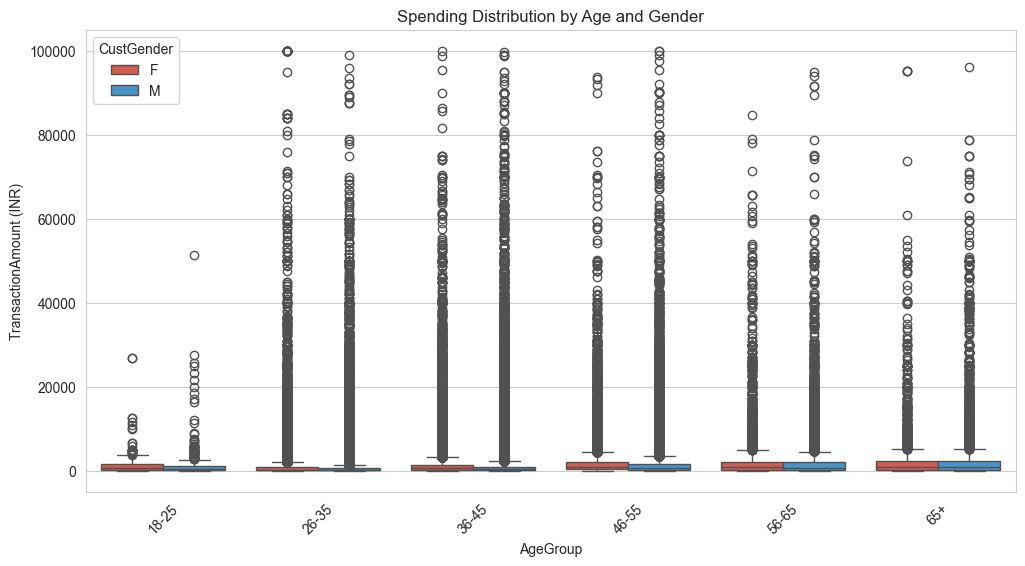

In [91]:
# Box plot by gender and age 
plt.figure(figsize=(12, 6))
sb.boxplot(data=bnk, x='AgeGroup', y='TransactionAmount (INR)', hue='CustGender', 
            palette=['#E74C3C', '#3498DB']) 
plt.title('Spending Distribution by Age and Gender')
plt.xticks(rotation=45)
plt.show()

In [92]:
# Distribution by age groups 
age_stats = bnk.groupby('AgeGroup', observed=True)['TransactionAmount (INR)'].describe()

print("="*80)
print("SPENDING DISTRIBUTION BY AGE GROUPS")
print("="*80)
print(age_stats.round(2))

# Show key insights
print("\n" + "="*80)
print("KEY INSIGHTS BY AGE GROUP:")
print("="*80)

for age_group in age_stats.index:
    mean_val = age_stats.loc[age_group, 'mean']
    median_val = age_stats.loc[age_group, '50%']
    count_val = age_stats.loc[age_group, 'count']
    
    print(f"\n{age_group} Age Group:")
    print(f"  - Customers: {int(count_val):,}")
    print(f"  - Avg Transaction: ₹{mean_val:,.2f}")
    print(f"  - Median Transaction: ₹{median_val:,.2f}")
    print(f"  - Distribution: {'Right-skewed (few high spenders)' if mean_val > median_val * 1.5 else 'Balanced'}")

SPENDING DISTRIBUTION BY AGE GROUPS
             count     mean      std  min     25%    50%      75%       max
AgeGroup                                                                   
18-25        586.0  1724.99  4083.62  0.0  150.00  500.0  1450.00  51350.00
26-35     236194.0   840.72  2866.60  0.0   98.00  250.0   688.65  99999.99
36-45     295434.0  1248.49  3410.60  0.0  186.00  450.0  1080.45  99999.00
46-55      79131.0  1837.76  4504.73  0.0  286.00  700.0  1700.00  99997.00
56-65      21624.0  2274.46  5378.64  0.0  280.13  803.0  2000.00  95000.00
65+        11224.0  2738.50  6572.27  0.0  300.00  900.0  2244.50  96046.00

KEY INSIGHTS BY AGE GROUP:

18-25 Age Group:
  - Customers: 586
  - Avg Transaction: ₹1,724.99
  - Median Transaction: ₹500.00
  - Distribution: Right-skewed (few high spenders)

26-35 Age Group:
  - Customers: 236,194
  - Avg Transaction: ₹840.72
  - Median Transaction: ₹250.00
  - Distribution: Right-skewed (few high spenders)

36-45 Age Group:
  - Cu

In [93]:
# Distribution by account balance groups 
print("\n" + "="*80)
print("DISTRIBUTION BY ACCOUNT BALANCE GROUPS")
print("="*80)
print(balance_stats.round(2))


DISTRIBUTION BY ACCOUNT BALANCE GROUPS
                 count     mean      std  min    25%    50%      75%       max
BalanceGroup                                                                  
Low           128847.0   851.31  2590.10  0.0   95.0  250.0   700.00  99000.00
Low-Medium    128845.0   884.55  2622.60  0.0  100.0  297.0   778.00  99000.00
Medium        128836.0  1043.67  2884.46  0.0  147.0  363.0   990.00  98672.75
Medium-High   128846.0  1393.32  3702.62  0.0  200.0  500.0  1231.00  95000.00
High          128839.0  1988.25  5221.88  0.0  255.0  680.0  1721.92  99999.99


3.Combined Analysis of All Variables

In [94]:
# Average spending by all groups combined - Fixed version
combined_analysis = bnk.groupby(['CustGender', 'AgeGroup', 'BalanceGroup'], observed=True)['TransactionAmount (INR)'].agg([
    'count', 'mean', 'median', 'std'
]).round(2)
print("Combined analysis:")
combined_analysis

Combined analysis:


count     mean   median      std
CustGender AgeGroup BalanceGroup                                  
F          18-25    Low              48  2001.00   543.00  5378.98
                    Low-Medium       57  1731.86   597.00  2805.72
                    Medium           34   443.03   101.00   877.94
                    Medium-High      10  2667.46  1757.31  2912.24
                    High             24  2716.40  1183.00  3255.74
           26-35    Low           14485   661.55   220.00  1739.84
                    Low-Medium    17572   758.63   255.00  2255.67
                    Medium        16850   839.52   300.00  2107.14
                    Medium-High   14622  1137.10   416.12  3049.25
                    High          11305  1835.17   500.00  6718.96
           36-45    Low           10016  1219.38   419.49  3084.99
                    Low-Medium    11992  1111.55   469.01  2494.26
                    Medium        14599  1209.77   501.00  2784.37
                    Medium-High   17698  1535.59   606.30  3580.42
                    High          19831  1945.38   760.00  4589.74
           46-55    Low            2229  1566.28   600.00  3657.96
                    Low-Medium     2400  1521.67   672.16  3560.59
                    Medium         3030  1754.47   755.00  3458.66
                    Medium-High    4590  2022.18   899.12  4284.43
                    High           6683  2559.04  1058.00  5574.24
           56-65    Low             639  2078.97   650.00  4744.43
                    Low-Medium      699  1621.09   660.00  3568.91
                    Medium          937  1897.17   685.00  4676.43
                    Medium-High    1613  2454.31   960.00  5680.87
                    High           2156  3417.32  1106.75  7569.86
           65+      Low             473  1622.99   500.00  4038.94
                    Low-Medium      447  1979.99   632.00  4263.38
                    Medium          567  2413.91   840.00  5480.79
                    Medium-High     792  2369.12   924.50  5616.96
                    High           1168  3502.30  1289.50  8026.48
M          18-25    Low             104   997.90   379.50  1602.73
                    Low-Medium      102  1136.44   500.00  2029.81
                    Medium           89  2310.34   600.00  4954.22
                    Medium-High      70   977.89   440.00  1837.03
                    High             48  4487.08  1363.00  9129.79
           26-35    Low           45124   571.99   173.00  2000.01
                    Low-Medium    41686   640.51   200.00  2268.92
                    Medium        32728   747.15   250.00  2292.16
                    Medium-High   24093  1008.93   303.45  3221.51
                    High          17729  1289.93   397.00  3732.59
           36-45    Low           43399   881.36   290.00  2539.04
                    Low-Medium    41744   891.81   300.00  2592.67
                    Medium        45394  1018.40   360.00  2874.05
                    Medium-High   46835  1294.38   500.00  3518.61
                    High          43926  1765.64   600.00  4667.53
           46-55    Low            8913  1332.87   500.00  3668.64
                    Low-Medium     8892  1408.04   504.95  3650.96
                    Medium        10857  1427.25   510.00  3543.37
                    Medium-High   13373  1726.78   700.00  4008.62
                    High          18164  2399.93   959.10  5805.15
           56-65    Low            2423  1567.49   500.00  3932.79
                    Low-Medium     2185  1388.86   500.00  3233.83
                    Medium         2423  1943.01   665.00  5209.32
                    Medium-High    3451  2163.99   820.00  5100.69
                    High           5098  2865.56  1118.52  5978.73
           65+      Low             994  2381.43   606.90  6387.99
                    Low-Medium     1066  1818.26   550.00  5140.55
                    Medium         1324  2323.24   612.00  5888.35
              

In [95]:
# Crosstab table - average spending
crosstab_mean = pd.crosstab(
    [bnk['CustGender'], bnk['AgeGroup']],   # index = Gender + AgeGroup
    bnk['BalanceGroup'],                    # columns = BalanceGroup
    values=bnk['TransactionAmount (INR)'],  # values to summarize
    aggfunc='mean'                          # function = mean spending
)

print("average spending for each gender–age–balance combination:")
crosstab_mean

average spending for each gender–age–balance combination:


BalanceGroup                 Low   Low-Medium       Medium  Medium-High  \
CustGender AgeGroup                                                       
F          18-25     2001.003333  1731.858596   443.029412  2667.462000   
           26-35      661.551776   758.628383   839.519287  1137.104372   
           36-45     1219.379053  1111.546811  1209.770666  1535.594380   
           46-55     1566.275949  1521.666996  1754.468165  2022.175054   
           56-65     2078.971706  1621.092833  1897.170971  2454.310267   
           65+       1622.992622  1979.994877  2413.912981  2369.120896   
M          18-25      997.901442  1136.437745  2310.342247   977.894000   
           26-35      571.985455   640.511799   747.145325  1008.932999   
           36-45      881.362224   891.805381  1018.401933  1294.378190   
           46-55     1332.871352  1408.042895  1427.252537  1726.780322   
           56-65     1567.486166  1388.863638  1943.007082  2163.990235   
           65+       2381.425362  1818.260544  2323.235846  2961.540995   

BalanceGroup                High  
CustGender AgeGroup               
F          18-25     2716.400000  
           26-35     1835.172578  
           36-45     1945.381294  
           46-55     2559.042397  
           56-65     3417.315278  
           65+       3502.296875  
M          18-25     4487.084375  
           26-35     1289.930527  
           36-45     1765.636114  
           46-55     2399.933215  
           56-65     2865.557401  
           65+       3463.243553

4.Data Visualization

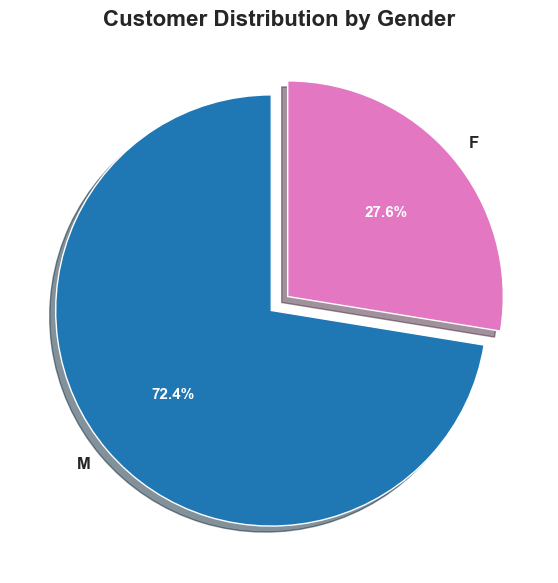

In [96]:
# Data – Gender distribution
gender_counts = bnk['CustGender'].value_counts()

# Colors for male and female
colors = ["#1f77b4", "#e377c2"]  # Deep blue for M, pink for F

# Explode effect – makes slices pop out slightly
explode = [0.05] * len(gender_counts)

# Create the pie chart
fig, ax = plt.subplots(figsize=(7,7), facecolor="white")

wedges, texts, autotexts = ax.pie(
    gender_counts, 
    labels=gender_counts.index,
    autopct='%1.1f%%',       # Show percentages
    startangle=90,           # Rotate for better layout
    colors=colors,
    explode=explode,         # Exploding slices
    shadow=True,             # Add shadow effect
    wedgeprops={'linewidth':1, 'edgecolor':'white'}  # Clean slice borders
)

# Title
ax.set_title("Customer Distribution by Gender", fontsize=16, weight="bold")

# Format labels and percentages
for text in texts:
    text.set_fontsize(12)
    text.set_weight("bold")
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_color("white")
    autotext.set_weight("bold")

plt.show()

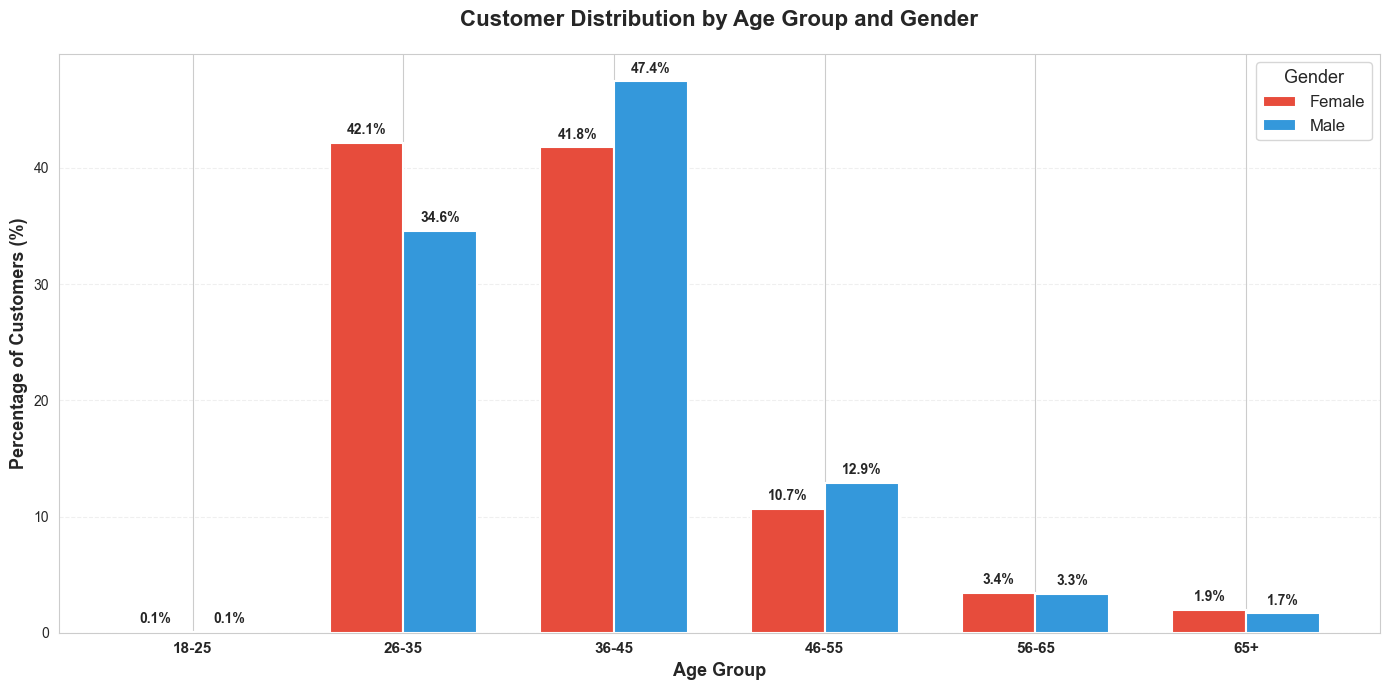

In [97]:
# 1. Create Age Groups if not already in your data
bnk['AgeGroup'] = pd.cut(
    bnk['Age'], 
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=['18-25','26-35','36-45','46-55','56-65','65+']
)

# 2. Count customers by AgeGroup & Gender
age_gender = bnk.groupby(['AgeGroup', 'CustGender'], observed=False).size().unstack(fill_value=0)
# 3. Split female and male series
female_age = age_gender['F']
male_age   = age_gender['M']

# 4. Convert to percentages of total per gender
female_pct = (female_age / female_age.sum()) * 100
male_pct   = (male_age / male_age.sum()) * 100

# 5. Plot grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor="white")

x = np.arange(len(female_pct))
width = 0.35

bars1 = ax.bar(x - width/2, female_pct, width, label='Female',
               color='#E74C3C', edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, male_pct, width, label='Male',
               color='#3498DB', edgecolor='white', linewidth=1.5)

# Add labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# Axis formatting
ax.set_xlabel('Age Group', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage of Customers (%)', fontsize=13, fontweight='bold')
ax.set_title('Customer Distribution by Age Group and Gender',
             fontsize=16, fontweight='bold', pad=20)

ax.set_xticks(x)
ax.set_xticklabels(female_pct.index, fontsize=11, fontweight="bold")

ax.legend(fontsize=12, title='Gender', title_fontsize=13)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.show()

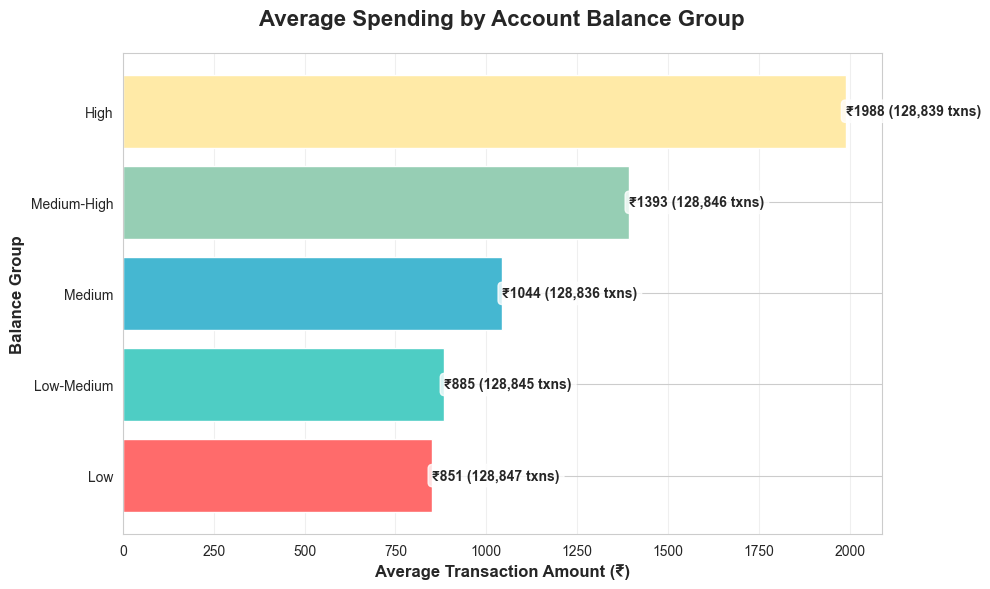

In [98]:
# Horizontal bar chart with statistics - Fixed version
balance_summary = bnk.groupby('BalanceGroup', observed=True)['TransactionAmount (INR)'].agg(['mean', 'count'])
balance_summary = balance_summary.sort_values('mean')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(balance_summary.index, balance_summary['mean'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])

# Add value labels
for i, (bar, count) in enumerate(zip(bars, balance_summary['count'])):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'₹{width:.0f} ({count:,} txns)',
            ha='left', va='center', fontsize=10, fontweight='bold', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_xlabel('Average Transaction Amount (₹)', fontsize=12, fontweight='bold')
ax.set_ylabel('Balance Group', fontsize=12, fontweight='bold')
ax.set_title('Average Spending by Account Balance Group', fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

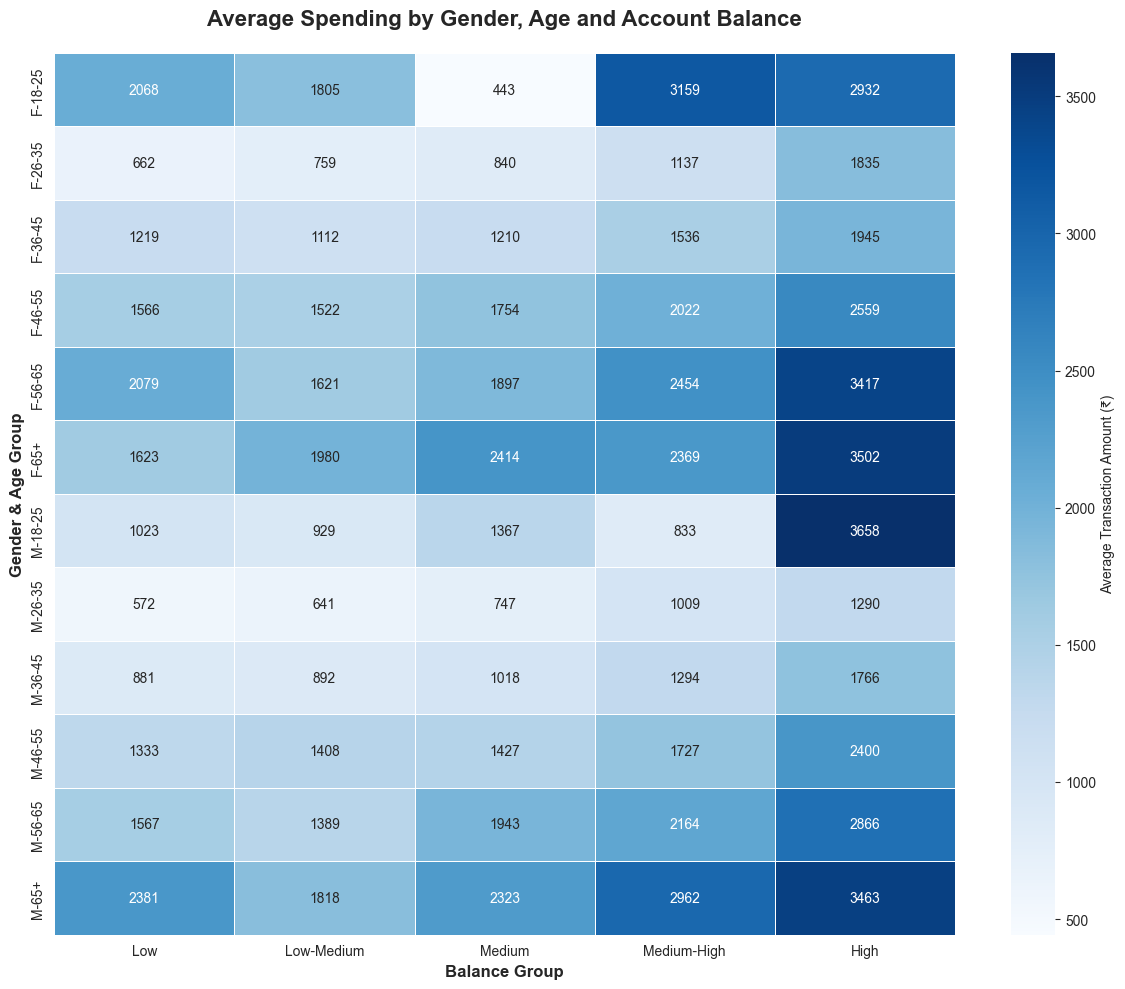

In [99]:
# Heatmap of average spending 
plt.figure(figsize=(12, 10))
pivot_table = bnk.pivot_table(values='TransactionAmount (INR)', 
                           index=['CustGender', 'AgeGroup'], 
                           columns='BalanceGroup', 
                           aggfunc='mean',
                           observed=False)  # Add this parameter

sb.heatmap(pivot_table, annot=True, fmt='.0f', cmap='Blues', 
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Average Transaction Amount (₹)'})

plt.title('Average Spending by Gender, Age and Account Balance', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Balance Group', fontsize=12, fontweight='bold')
plt.ylabel('Gender & Age Group', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

This heatmap plots average transaction spending by gender, age group, and balance tier.
Dark blue = higher spending → immediate hotspots.
    
1. Highest Spenders are in the 'High' Balance Group
•	The single highest average spending is 3658 ₹, recorded by Males aged 18-25 (M 18-25) in the High Balance Group.
•   Other groups showing exceptionally high spending in the 'High' balance category are Females 65+ (3502 ₹) and Males 65+ (3463 ₹). This indicates that while young high-balance males spend the most, the older high-balance groups are also crucial high-value segments.
2. Lowest Spending and Notable Outliers
•	The overall lowest average spending is 443 ₹, recorded by Females aged 18-25 (F 18-25) in the Medium Balance Group.
•	This F 18-25 group is an anomaly, as their spending drops significantly in the 'Medium' balance group compared to their 'Low' (2068 ₹) and 'High' (2932 ₹) balance counterparts.
3. Consistent Mid-to-High Spenders
The older middle-aged segments (46-65) tend to show high and consistent average spending across all balance groups, making them a reliable segment of the customer base.

PHASE 5: EXECUTIVE CUSTOMER INSIGHTS & STRATEGY REPORT

________________________________________
Full Data Understanding: Customer Segmentation and Value Drivers
This analysis integrates customer spending, balance group strategy, and demographic volume to identify the bank's primary revenue drivers, retention risks, and growth opportunities.
A. Key Demographic and Spending Insights
Young Males (18–25) - High Balance: They are the highest-value customers in the dataset, showing an extreme “wealth-spending multiplier” (a 4.5x jump from low to high balance). They are the bank's primary high-value growth engine.

Senior Women (56+) - High Balance: These women are more engaged and higher-spending than male peers at the same tier. They represent highly loyal, stable clients critical for retention.

Leakage Risk (F 18–25 Medium Balance): Young females at the medium balance level severely underperform (₹443 avg. spend). This segment represents a leakage problem that must be addressed before any upselling efforts can succeed.

Future Loyalty Gap (M 26–35 Low Balance): This is a large volume segment but shows the weakest overall engagement (₹572 avg. spend). If ignored, this group is at high risk of competitor loss and long-term unprofitability.
________________________________________
B. Gender & Age Dynamics: Identifying Key Segments
1. High-Impact Segments (The Growth & Retention Engines)
•	Young Males (18–25) - High Balance: Show an extreme “wealth-spending multiplier” (a 4.5x jump from low to high balance), making them the highest-value customers in the entire dataset (3658 ₹ avg. spend). They are the bank's high-value growth engine.
•	Senior Women (56+) - High Balance: More engaged and higher-spending than male peers at the same senior level. They represent highly loyal, stable customers and are critical to retain.
2. Major Risk & Underperformance Segments
•	Young Females (18–25) - Medium Balance: Grossly underperform at medium balances (443 ₹ avg.), suggesting a fundamental leakage problem or a mismatch in product offering for this group.
•	Males 26–35 - Low Balance: A large volume segment, but show the weakest overall engagement (572 ₹ avg. spend). If not fixed, this group may remain unprofitable and is at high risk of competitor loss (future loyalty gap).
3. Core & High-Potential Segments
•	Females 26–45 - High Balance: Consistently outspend male peers at the same high-balance tier, signaling strong value once their balances grow.
•	Seniors 65+: Gender differences in spending flatten out (spending is nearly equal). They are consistent customers but offer less growth potential than the 56+ group.
________________________________________
C. Critical Insights for the Bank: The Strategic Takeaways
1.	High-Value Growth Engine: Focus on nurturing young high-balance males (18-25) to maximize their lifetime value.
2.	Leakage Risk: Immediate action is needed to fix the underperformance of young medium-balance females (18-25). This indicates a structural issue in product fit or engagement for this group.
3.	Future Loyalty Gap: Deploy proactive engagement strategies for low-balance males 26–35 to prevent them from becoming unprofitable or migrating to a competitor.
4.	Senior Female Premium: Prioritize retention and personalized service for senior high-balance women (56+), recognizing their status as loyal, high-spending, high-value clients.

Strategic Recommendations: A Data-Driven Action Plan
The following recommendations are targeted based on customer volume, average spending, and identified leakage/growth risks across the bank's customer segments.
1. Protect and Grow the Top-Tier Clients
The highest revenue is generated by a small, specific group of customers. The strategy must be retention-focused and personalized:
•	Focus: Young High-Balance Males (18–25) and Senior High-Balance Women (56+).
•	Action: Provide elite experiences, such as dedicated wealth management advisors, VIP customer service, and exclusive, high-yield product access. Retention efforts must acknowledge the demographic differences (e.g., career-focused offerings for the young males vs. legacy/retirement planning for senior women).
2. Fix Critical Weak Engagement Pockets
Two large segments pose the highest risk of unprofitability or lost loyalty. Action here requires targeted investigation and intervention:
•	Solve the Anomaly: Address the Young Female Medium-Balance (18–25) segment. Since they severely underperform, develop tailored products or services that match their lifestyle and spending habits, solving the current "leakage" problem.
•	Activate the Core: Proactively engage Low-Balance Males (26–35) before they defect. This large segment is currently a high-risk loyalty gap. Use personalized communications and small incentives to drive engagement and move them to higher-spending tiers.
3. Maximize Lifetime Value Across the Base
Shift focus from reactive service to proactive growth across the medium-to-high balance segments:
•	Predictive Upselling: Build models to identify customers who are financially ready to upgrade tiers (e.g., moving from Low-Medium to Medium-High balance).
•	Action: Trigger personalized offers and benefits (e.g., waiving a fee, a higher interest rate) the moment a customer qualifies to encourage upward migration and increase their average transaction value.
4. Differentiate Product Offerings by Life Stage
To capture value across the entire age spectrum, the product portfolio must align with core demographic needs:
•	Young Professionals (18–35): Focus on dynamic, easy-to-use products like gamified savings, high-cashback rewards, and tools for managing early career finances.
•	Families & Established Professionals (36–55): Center offerings around major financial commitments, such as mortgage-linked benefits, insurance tie-ins, and family financial planning tools.
•	Seniors (65+): Provide stability and security with products focused on estate planning, healthcare bundles, and white-glove, easy-access service that prioritizes convenience and trust.

Actions & Implementation Plan
The plan is divided into three phases, addressing the high-value segments, high-risk segments, and long-term systemic improvements.
A. Short-Term Actions (0–6 months)
The initial focus is on diagnosis and immediate retention of critical customer groups.
1.	Customer Research: Launch focused groups and surveys targeting young females 18–25 in the medium balance group. This is crucial to understand why they underperform (443 ₹ avg. spend) and solve this leakage problem.
2.	Engagement Campaign: Run a campaign offering cashback on essential spending for low-balance males 26–35. The goal is to drive basic activity and close the loyalty gap before this large, low-spending segment defects.
3.	VIP Retention: Immediately assign dedicated relationship managers to the top 200 high-balance clients, prioritizing the highest spenders: young high-balance males (18-25) and senior high-balance women (56+). This protects the core revenue stream.
B. Mid-Term Actions (6–12 months)
The focus shifts to product development and segment-specific value creation based on earlier research.
1.	Product Launch: Introduce a "Young Professionals Bundle" for adults 18–35. This would include perks like a salary deposit bonus, a first credit card, and savings gamification to successfully onboard and grow the next generation of top spenders.
2.	Digital Tools: Develop a dedicated budgeting and bill-splitting app targeted specifically at young female customers. This action directly addresses the finding from the short-term research by providing a utility that encourages frequent digital engagement.
3.	Senior Elite Club: Launch a loyalty program for senior high-balance women 56+, offering exclusive perks related to health, travel, and estate planning. This solidifies loyalty with a stable and highly valuable demographic.
C. Long-Term Actions (12–24 months)
The focus is on sustainable scaling and data-driven optimization across the entire customer journey.
1.	Predictive Migration Engine: Develop an AI model to forecast when a customer is likely to experience significant balance growth. This system will then automatically trigger personalized tier-upgrade offers, maximizing customer lifetime value.
2.	Cross-Selling Expansion: Systematically implement insurance, investment, and mortgage tie-ins for mid-to-high balance clients. This deepens the relationship, increasing product holdings and making it much harder for customers to switch banks.
3.	Churn Prevention: Integrate an early warning system to monitor customer behavior for signs of inactivity or disengagement. This allows for proactive intervention before a client decides to leave.

Measurement & KPIs and Final Executive Takeaway 
This section defines the success metrics for the implementation plan and provides the ultimate business summary.
A. Measurement & KPIs (Key Performance Indicators)
The bank's success over the next 12 months will be measured by the following targets:
•	18–25 High-Balance Males (Retention Focus): The Churn Rate must be reduced from the current ∼5% to less than 1%.
•	18–25 Medium-Balance Females (Leakage Fix): Average Spend must double from ₹443 to ₹886, signaling the success of new targeted products.
•	26–35 Low-Balance Males (Reactivation): Average Spend must increase by 30% from ₹572 to ₹750. Additionally, 
Transaction Frequency must increase by 40% above baseline.
•	56+ High-Balance Females (Loyalty Deepening): Cross-Product Usage must increase by 25% above the current low baseline.
•	Overall High Balance Segment: The Share of Total Spend must grow from 60% to 70%.
•	Bank-wide Financial Goal: Net Transaction Volume must see an increase of +₹10M in annualized growth.
B. Final Executive Takeaway
The bank’s strategic pathway to improved growth and profitability is concentrated in three crucial leverage points:
1.	Protect: Secure the loyalty and revenue of the young high-balance males and senior high-balance women—the bank's core revenue drivers.
2.	Fix: Solve the severe leakage problem identified in young medium-balance females 
and actively reactivate low-balance males 26–35 before they become competitors' customers.
3.	Grow: Use predictive analytics to automate and accelerate the movement of qualified customers upward through the balance tiers.
By focusing on these three levers, the bank is positioned to generate over ₹10M in additional annual volume, 
drastically improve customer retention rates, and build substantial long-term customer value.